In [1]:
# %% Cell 1: Imports and Configuration
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# CONFIGURATION - Fine-tune formatting here
# =============================================================================

# --- File Path ---
FILE_PATH = "C:\\Users\\skar\\Box\\_Saura_Self\\Proj - Water tool analysis\\data\\energy compare\\Comparison.csv"  # <-- Edit this to your CSV file path

# --- Figure Size ---
FIG_WIDTH = 9
FIG_HEIGHT = 6

# --- Y-Axis Limits ---
Y_LIMIT_MODE = "auto"   # "auto" = pad above max error bar, "manual" = use Y_MAX
Y_MAX = 2.5             # Only used if Y_LIMIT_MODE = "manual"
Y_PAD_FACTOR = 1.15     # Only used if Y_LIMIT_MODE = "auto"; 1.15 = 15% padding above tallest bar+error

# --- Bar / Error Bar Appearance ---
BAR_COLOR = "#4C72B0"
BAR_EDGECOLOR = "black"
BAR_ALPHA = 0.8
BAR_WIDTH = 0.6
ERROR_COLOR = "red"
ERROR_LINEWIDTH = 1        # <-- increase for thicker vertical whisker lines
ERROR_CAPSIZE = 5
ERROR_CAPTHICK = 1.0       # <-- increase for thicker horizontal cap lines
CAP_HALF_WIDTH = 0.3     # <-- increase for wider horizontal caps

# --- Axis Labels & Title ---
TITLE = "Electricity Consumed On-Site with Estimated Intensity Range"
TITLE_FONTSIZE = 16
XLABEL = "Facilities"
XLABEL_FONTSIZE = 13
YLABEL = "Electricity Intensity (kWh/m³)"
YLABEL_FONTSIZE = 13

# --- Tick Labels ---
XTICK_ROTATION = 90
XTICK_FONTSIZE = 9
YTICK_FONTSIZE = 11

# --- Grid ---
SHOW_GRID = True
GRID_AXIS = "y"
GRID_ALPHA = 0.3
GRID_LINESTYLE = "--"

# --- Layout ---
TIGHT_LAYOUT = True
BOTTOM_MARGIN = 0.25



In [2]:
# %% Cell 2: Load and Prepare Data

# Load raw CSV; first two rows are multi-level headers, data starts at row index 2
raw = pd.read_csv(FILE_PATH, header=None)

# The actual data rows start at row index 2 (0-indexed).
# Row 0 = group headers, Row 1 = column names
data = raw.iloc[2:].reset_index(drop=True)

# Drop rows with column PREDICTED_WRRF_TT_CODE having no value
data = data[data[2].notna()].reset_index(drop=True)

# Assign readable column letters for reference (A=0, B=1, ... AC=28)
# Column indices we need:
#   A  (0)  -> CWNS_ID
#   E  (4)  -> Electricity_consumed_onsite_kWh_per_m3
#   K  (10) -> Electricity Intensity (kWh/m3) - Flow method
#   L  (11) -> Variation (Flow method)
#   N  (13) -> Electricity Intensity by A method
#   O  (14) -> Variation Method A
#   P  (15) -> Electricity Intensity by B method
#   Q  (16) -> Variation Method B
#   R  (17) -> Electricity Intensity BP Method
#   S  (18) -> Variation Elec Method BP
#   T  (19) -> Electricity Intensity by T Method
#   U  (20) -> Variation Elec Method T
#   Z  (25) -> Electricity Intensity UP A method
#   AA (26) -> Variation Method A (UP)
#   AB (27) -> Electricity Intensity UP B method
#   AC (28) -> Variation Method B (UP)
#   AE (30) -> Facility Name

COL_ID = 30
COL_MEDIAN = 4

ESTIMATE_COLS = [11, 14, 16, 18, 20, 26, 28]
VARIANCE_COLS = [12, 15, 17, 19, 21, 27, 29]

df = pd.DataFrame()

df["Facility_name"] = data.iloc[:, COL_ID].astype(str).str.strip()
df["Electricity_consumed"] = pd.to_numeric(data.iloc[:, COL_MEDIAN], errors="coerce")

for i, (est_col, var_col) in enumerate(zip(ESTIMATE_COLS, VARIANCE_COLS)):
    df[f"est_{i}"] = pd.to_numeric(data.iloc[:, est_col], errors="coerce")
    df[f"var_{i}"] = data.iloc[:, var_col]

df = df.dropna(subset=["Electricity_consumed"]).reset_index(drop=True)
print(f"Loaded {len(df)} valid rows.")

Loaded 36 valid rows.


In [3]:
# %% Cell 3: Compute Min/Max from valid estimates

min_vals = []
max_vals = []

for idx, row in df.iterrows():
    valid_estimates = []
    for i in range(len(ESTIMATE_COLS)):
        est_val = row[f"est_{i}"]
        var_val = row[f"var_{i}"]
        var_is_valid = False
        if pd.notna(var_val):
            var_str = str(var_val).strip()
            if var_str != "" and var_str.lower() != "nan":
                var_is_valid = True
        if pd.notna(est_val) and var_is_valid:
            valid_estimates.append(est_val)

    if valid_estimates:
        min_vals.append(min(valid_estimates))
        max_vals.append(max(valid_estimates))
    else:
        min_vals.append(row["Electricity_consumed"])
        max_vals.append(row["Electricity_consumed"])

df["est_min"] = min_vals
df["est_max"] = max_vals
df["err_lower"] = (df["Electricity_consumed"] - df["est_min"]).clip(lower=0)
df["err_upper"] = (df["est_max"] - df["Electricity_consumed"]).clip(lower=0)


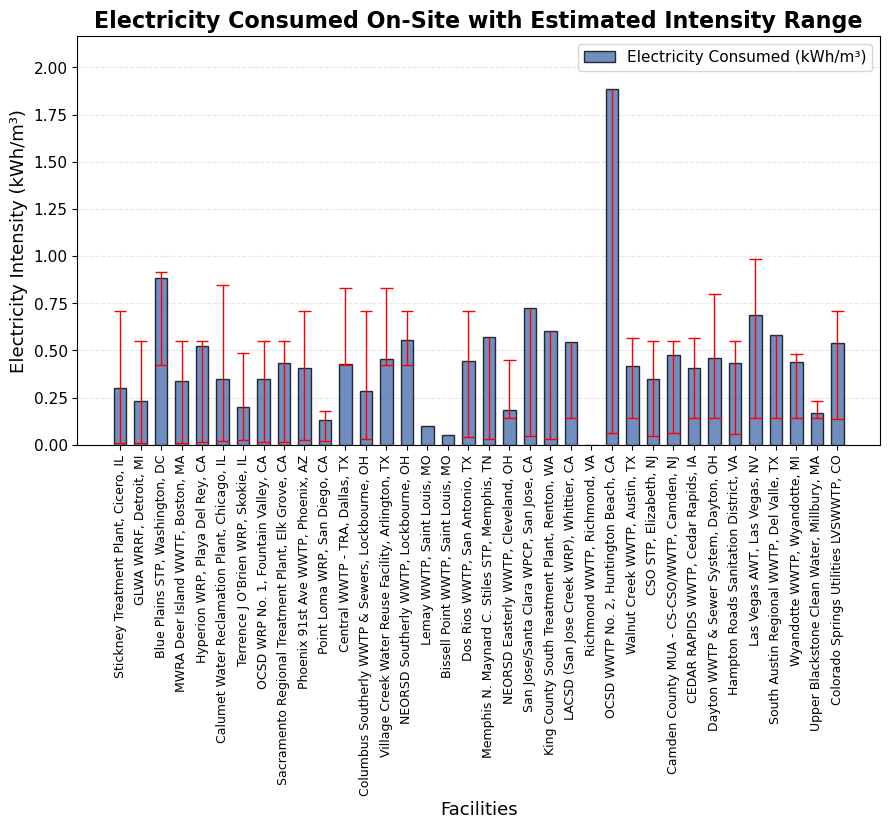

In [4]:
# %% Cell 4: Plot

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

x = np.arange(len(df))
errors = np.array([df["err_lower"].values, df["err_upper"].values])

ax.bar(x, df["Electricity_consumed"], width=BAR_WIDTH, color=BAR_COLOR,
       edgecolor=BAR_EDGECOLOR, alpha=BAR_ALPHA,
       label="Electricity Consumed (kWh/m³)", zorder=3)

"""ax.errorbar(x, df["Electricity_consumed"], yerr=errors, fmt="none",
            ecolor=ERROR_COLOR, elinewidth=ERROR_LINEWIDTH,
            capsize=ERROR_CAPSIZE, capthick=ERROR_CAPTHICK,
            label="Estimated Intensity Range (min–max)", zorder=4)"""

# Plot error bars — only draw whiskers where error > 0

for i in range(len(df)):
    lower = errors[0, i]
    upper = errors[1, i]
    val = df["Electricity_consumed"].iloc[i]

    if lower > 0:
        ax.vlines(x[i], val - lower, val,
                  color=ERROR_COLOR, linewidth=ERROR_LINEWIDTH, zorder=4)
        ax.hlines(val - lower, x[i] - CAP_HALF_WIDTH, x[i] + CAP_HALF_WIDTH,
                  color=ERROR_COLOR, linewidth=ERROR_CAPTHICK, zorder=4)

    if upper > 0:
        ax.vlines(x[i], val, val + upper,
                  color=ERROR_COLOR, linewidth=ERROR_LINEWIDTH, zorder=4)
        ax.hlines(val + upper, x[i] - CAP_HALF_WIDTH, x[i] + CAP_HALF_WIDTH,
                  color=ERROR_COLOR, linewidth=ERROR_CAPTHICK, zorder=4)


# --- Y-Axis Limit (THE FIX) ---
if Y_LIMIT_MODE == "manual":
    ax.set_ylim(0, Y_MAX)
else:
    top = (df["Electricity_consumed"] + df["err_upper"]).max()
    ax.set_ylim(0, top * Y_PAD_FACTOR)

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(df["Facility_name"], rotation=XTICK_ROTATION,
                   fontsize=XTICK_FONTSIZE, ha="center")
ax.set_xlabel(XLABEL, fontsize=XLABEL_FONTSIZE)
ax.set_ylabel(YLABEL, fontsize=YLABEL_FONTSIZE)
ax.set_title(TITLE, fontsize=TITLE_FONTSIZE, fontweight="bold")
ax.tick_params(axis="y", labelsize=YTICK_FONTSIZE)

if SHOW_GRID:
    ax.grid(axis=GRID_AXIS, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, zorder=0)

ax.legend(fontsize=11, loc="upper right")

if TIGHT_LAYOUT:
    plt.tight_layout()
    plt.subplots_adjust(bottom=BOTTOM_MARGIN)

plt.show()